In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
import sys

sys.path.append("../")
sys.path.append("../../../")
import visual_discrim_functions
import plotting
import regression

import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.stats as stats 

#import umap

import torch #pytorch
import torch.nn as nn

from sklearn.preprocessing import StandardScaler

In [2]:
visual_discrim_functions.get_rc_params()
mouse_list = visual_discrim_functions.get_mouse_list()
df, df_box = visual_discrim_functions.get_all_tolias_mice(mouse_list, path="/data/celia/ar_data/ar_data/",
                                                          load_dlc=True
                                                          )

Imagingsource_30559_2024-02-26_1
Imagingsource_30559_2024-02-20_1
Imagingsource_30559_2024-02-19_1
Imagingsource_30559_2024-02-16_1
Imagingsource_30559_2024-02-15_1
Imagingsource_30559_2024-02-14_1
Imagingsource_30559_2024-02-13_1
Imagingsource_30561_2024-02-16_1
Imagingsource_30561_2024-02-19_1
Imagingsource_30561_2024-02-20_1
Imagingsource_30561_2024-02-21_1
Imagingsource_30561_2024-02-22_1
Imagingsource_30561_2024-02-23_1


In [3]:
df = visual_discrim_functions.create_bins(data=df, spatial_ybins=[-13, 24, 50])
df = df[df.trial_length<=5]
df = df [(df.trial_rewarded > 0.5) & (df ["trial_tortuosity"] < 100)]

In [4]:
df.to_pickle("df.pickle")
df_box.to_pickle("df_box.pickle")

# LSTM

In [3]:
df = pd.read_pickle("df.pickle")
df_box = pd.read_pickle("df_box.pickle")

In [4]:
df["binary_aperture"] = (df["aperture"] > 7).astype(int)
failures = df[df.trial_rewarded < 0.5]

In [7]:
features = ["norm_x", "y", "heading_dir", "head_angle", "trial_tortuosity", "trial_init_x", "trial_length", "trial_init_y", "binary_aperture", "velocity", "acceleration_x", "heading_dir_velocity", "heading_dir_acceleration"]
names = ["x", "y", "head", "body",  "tort", "init_x", "length", "init_y", "aperture", "velocity", "acceleration", "heading_dir_velocity", "heading_dir_acceleration"]
n_splits = 5

In [6]:
df["session_trial"] = df['session'].astype(str) + '_' + df['trial'].astype(str)


In [7]:
multi_data = []
multi_labels = []
sessions = []

for session in df.session_trial.unique():
    df_session = df[df["session_trial"]==session]
    points = df_session[features].values.T
    
    multi_data.append(torch.Tensor(StandardScaler().fit_transform(points.T))[:,None,:])
    multi_labels.append(torch.Tensor(np.expand_dims(df_session.trial_R_choice.values, axis=1).astype(int)))#[:,None])
    sessions.append(np.expand_dims(df_session.session.values, axis=1))
    
print(multi_data[0].shape, multi_labels[0].shape)

torch.Size([160, 1, 13]) torch.Size([160, 1])


In [9]:
# from torch.utils.data import TensorDataset, DataLoader
# dataset = TensorDataset(X_train_tensors_final, y_train_tensors_final)

# batch_size = 64
# data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [8]:
df = pd.read_pickle("df.pickle")
df_box = pd.read_pickle("df_box.pickle")

df["binary_aperture"] = (df["aperture"] > 7).astype(int)
df["session_trial"] = df['session'].astype(str) + '_' + df['trial'].astype(
    str)

# Train model
df, model, val_index = regression.train_lstm(df,
                                    label=features,
                                    learning_rate=0.01,
                                    num_layers=1,
                                    hidden_units=16,
                                    output_size=1,
                                    num_epochs=10)

print(df.session.unique().shape)
print(df["session_trial"].values[val_index].shape)


Epoch [0/10], Train Loss: 0.0132, Test Loss: 0.0363
(13,)
(554,)


In [10]:
def plot_proba_per_trial(df, trials, logdir=None, save=None):
    fig, ax = plt.subplots(5, 3, figsize=(15, 15))
    ax = ax.flatten()
    for session_id, session in enumerate(df.session.unique()):
        for trial_id, trial in df[df["session"] == session].groupby(["session_trial"]):
            if trial_id[0] in trials:
                
                # Reset index within each group for a uniform timescale
                trial = trial.reset_index(drop=True)
                sns.lineplot(data=trial,
                             x="bin_centers",
                             y="pred",
                             ax=ax[session_id],
                             errorbar="se")
            else:
                continue

    if save is not None:
        plt.savefig(logdir + f"{save}_proba_plot.png")

In [17]:
val_index

array([ 429,  699, 1100, 1478,  112, 1843,  159, 1193,  217,  470,  923,
        370, 1056,  755,  443, 1303,  814, 1300, 1213, 1685, 1825,  485,
       1553,  800, 1588,  459, 1788, 1014,  562,  588,  175,  100, 1292,
       1140,  253,  213, 1180,  393,  989, 1817,  791, 1550, 1096,  195,
        345,  292,  403,  745,  130,  220,  904, 1115,  471, 1630,  590,
       1692, 1377,  932, 1002,  757,   63,  162, 1495,  854,  666, 1175,
        203,  379,   67, 1027, 1221, 1033, 1587, 1537,  743,  326, 1039,
        693,  717,  347, 1214,  601,  767,   25, 1075, 1190,  114,  792,
       1022,  786,  662, 1450,  573, 1134, 1154, 1502,   33, 1541,  410,
       1471, 1529, 1272,  709, 1679,  687, 1146,  243,  813,  899, 1735,
       1507,  645, 1695, 1784,  618,  375, 1545, 1748,  782,  940,  993,
       1376,  276, 1742,   37,  765,  153,   13,  592,  963,  935, 1296,
        169, 1447, 1546, 1360,  534,  624, 1461, 1807, 1331, 1682, 1019,
       1009, 1756, 1264, 1465, 1196,  881,  445, 18

In [21]:
sessions_trials = df.session_trial.unique()[val_index]

In [24]:
df[df.session_trial.isin(df.session_trial.unique()[val_index])]

,index,level_0,time,step,step_time,trial,x,y,head_dir,mouse_can_report,...,head_angle,head_angle_velocity,heading_dir_velocity,head_angle_acceleration,heading_dir_acceleration,bins,bin_centers,binary_aperture,session_trial,pred
226,226,2,1970-01-01 00:01:17.800,3887.00,77.804429,4.0,-2.302528,3.111412,35.495216,0.0,...,-9.197279,295.079486,-23.691518,1361.423462,307.474961,"(2.857, 3.612]",-21.7655,0,30559_2024-02-26_1_4.0,0.034468
227,227,2,1970-01-01 00:01:17.820,3888.00,77.827367,4.0,-2.648501,4.946622,32.546841,1.0,...,-3.293254,322.319138,-17.539489,2612.172193,774.112599,"(4.367, 5.122]",-20.2555,0,30559_2024-02-26_1_4.0,0.034652
228,228,2,1970-01-01 00:01:17.840,3888.75,77.845319,4.0,-3.090730,6.261979,30.876915,1.0,...,3.695486,399.566374,7.272986,-3807.225319,2356.402959,"(5.878, 6.633]",-18.7445,0,30559_2024-02-26_1_4.0,0.034068
229,229,2,1970-01-01 00:01:17.860,3889.50,77.863272,4.0,-3.532960,7.577336,29.206989,1.0,...,12.689401,170.030125,76.716630,-12278.624771,1948.551432,"(7.388, 8.143]",-17.2345,0,30559_2024-02-26_1_4.0,0.046271
230,230,2,1970-01-01 00:01:17.880,3891.00,77.895186,4.0,-4.160904,8.873547,26.323557,1.0,...,10.496691,-91.578617,85.215043,-5095.473618,-482.476271,"(8.143, 8.898]",-16.4795,0,30559_2024-02-26_1_4.0,0.046950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157268,14320,164,1970-01-01 01:00:31.560,181373.00,3631.563600,166.0,-15.209377,22.929094,57.141033,1.0,...,6.080996,-266.054017,201.226695,3377.132283,2912.639354,"(22.49, 23.245]",-2.1325,0,30561_2024-02-23_1_166.0,0.015285
157269,14321,164,1970-01-01 01:00:31.580,181374.25,3631.586788,166.0,-15.927977,22.838662,57.139679,1.0,...,2.137751,-134.566245,293.286622,7969.082231,723.418497,"(22.49, 23.245]",-2.1325,0,30561_2024-02-23_1_166.0,0.014645
157270,14322,164,1970-01-01 01:00:31.600,181375.50,3631.609976,166.0,-16.646577,22.748229,57.138325,1.0,...,0.698346,52.709272,230.163435,6825.358144,-5962.803281,"(22.49, 23.245]",-2.1325,0,30561_2024-02-23_1_166.0,0.014810
157271,14323,164,1970-01-01 01:00:31.620,181376.25,3631.630266,166.0,-17.108590,22.631948,56.884041,1.0,...,4.246122,138.448081,54.774491,1169.951586,-4727.111785,"(22.49, 23.245]",-2.1325,0,30561_2024-02-23_1_166.0,0.027040


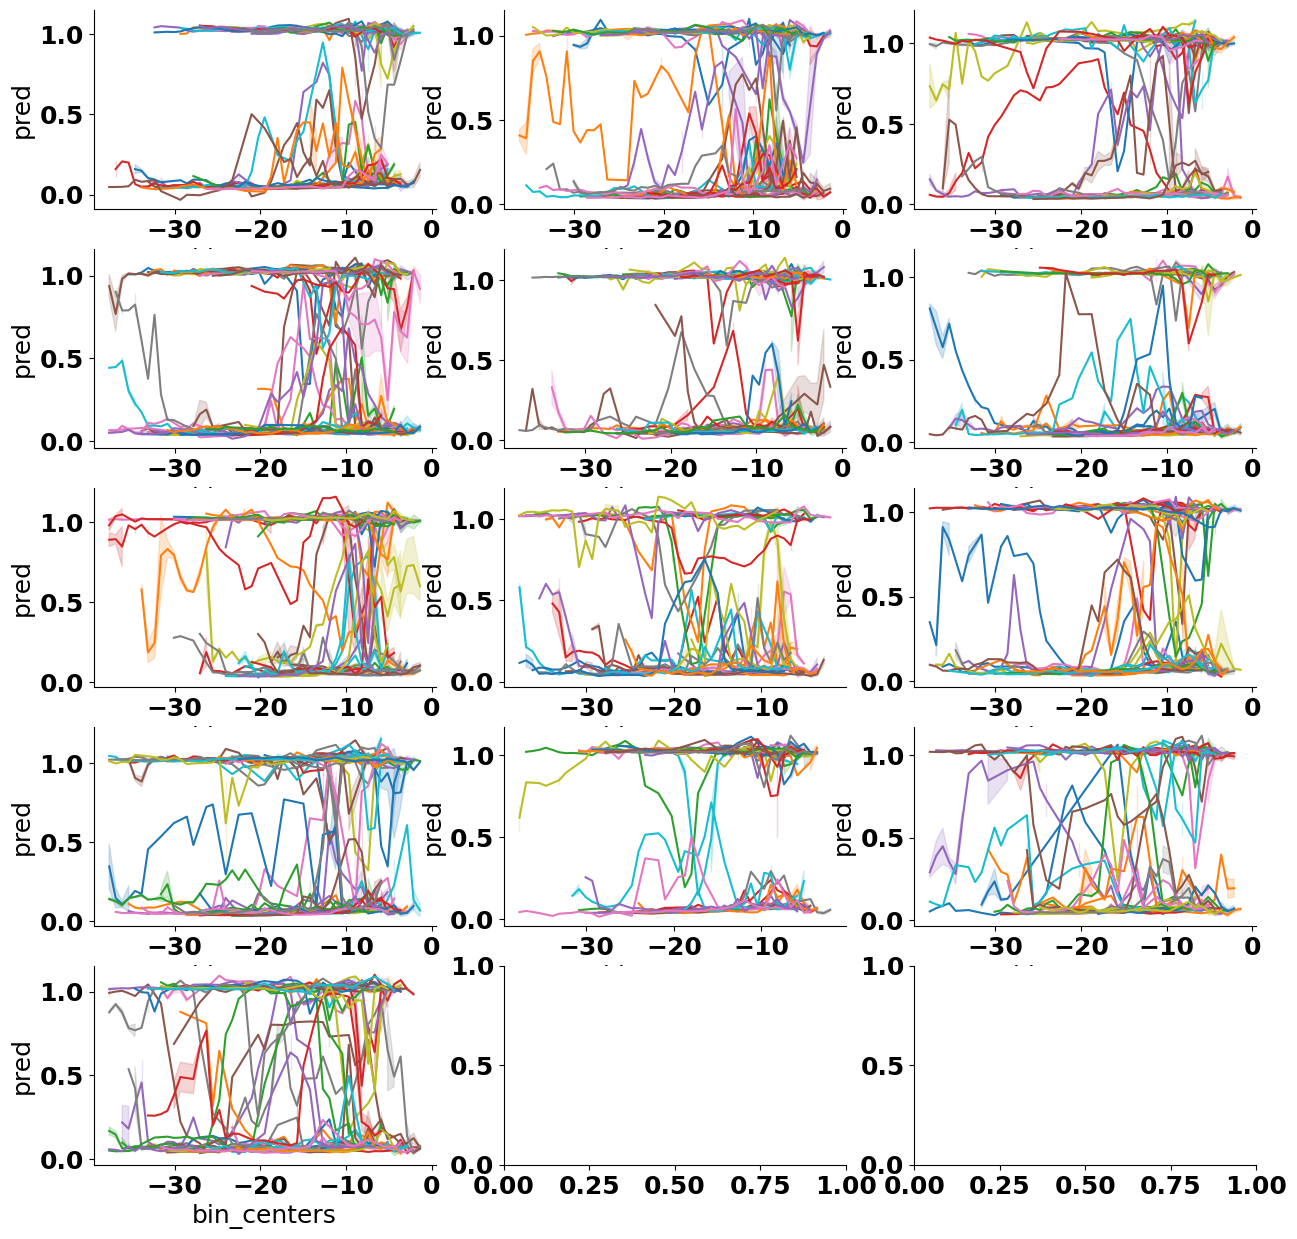

In [25]:
# Save plots of interest
plot_proba_per_trial(df, trials=df["session_trial"].unique()[val_index])

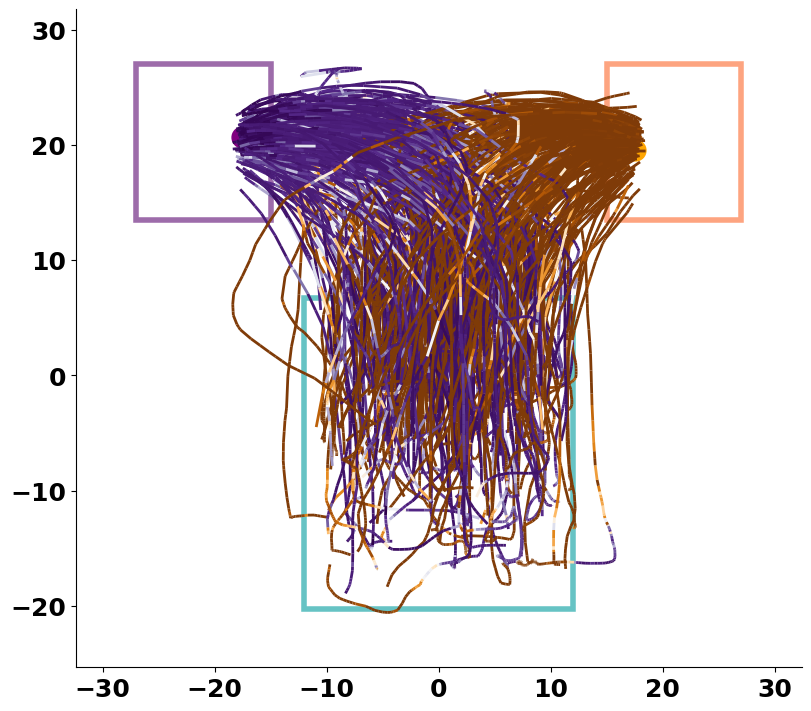

In [26]:
regression.plot_decision_points_on_trajectory(df,
                                                df_box,
                                                trials=df["session_trial"].unique()[val_index])

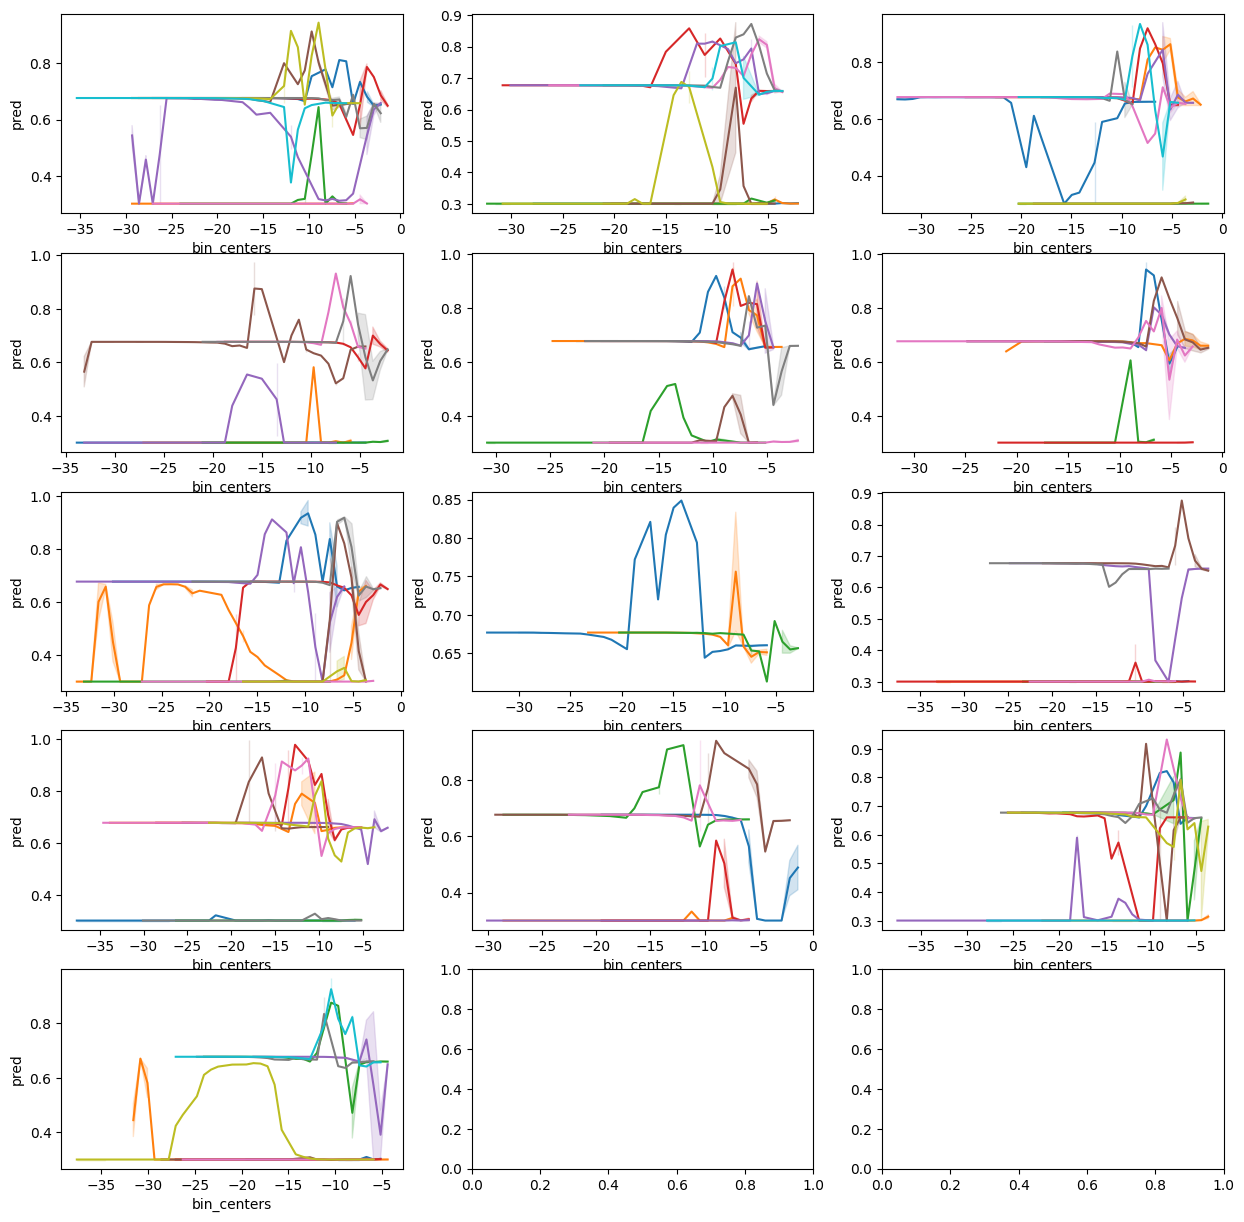

In [30]:
regression.plot_proba_per_trial(df, trials=list(range(25,35)))

In [ ]:
decision_point = df.groupby(["session", "trial"], as_index=False).apply(lambda x: regression.find_decision_point_per_trial(x, 0.1))


In [ ]:
decision_point

In [36]:
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm

In [37]:
def plot_decision(df, df_box, color="red", session="30559_2024-02-19_1", trials=list(range(25, 30)), ax=None):

    if ax is None: 
        fig = plt.figure(figsize = (8,7), constrained_layout=True)
        gs = plt.GridSpec(1, 1, figure=fig)
        ax = fig.add_subplot(gs[0, 0])

    plotting.plot_all_boxes(ax=ax ,df_box=df_box)

    mpl.rcParams['lines.markersize'] = 15
    ax.scatter(df_box["right_reward_x"], df_box["right_reward_z"], color="orange")
    ax.scatter(df_box["left_reward_x"], df_box["left_reward_z"], color="purple")
    
    for trial in df[df["session"]==session].trial.unique():
        mpl.rcParams['lines.markersize'] = 2
        if trial in trials:
            #ax.scatter(df[(df["session"]==session) & (df["trial"]==trial)]["x"], 
            #        df[(df["session"]==session) & (df["trial"]==trial)]["y"],
            #        c=df[(df["session"]==session) & (df["trial"]==trial)]["pred"],
            #        cmap="magma")
            
            
            # Create points from x and y for LineCollection
            points = np.array([df[(df["session"]==session) & (df["trial"]==trial)]["x"], 
                               df[(df["session"]==session) & (df["trial"]==trial)]["y"]]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)

            # Create a LineCollection
            lc = LineCollection(segments, cmap='PuOr_r', norm=plt.Normalize(0, 1))
            lc.set_array(df[(df["session"]==session) & (df["trial"]==trial)]["pred"])
            lc.set_linewidth(2)

            ax.add_collection(lc)
            ax.autoscale()
            ax.margins(0.1)
            

            ax.legend([],[], frameon=False)
        else: 
            continue

--> computing for treshold  0.2


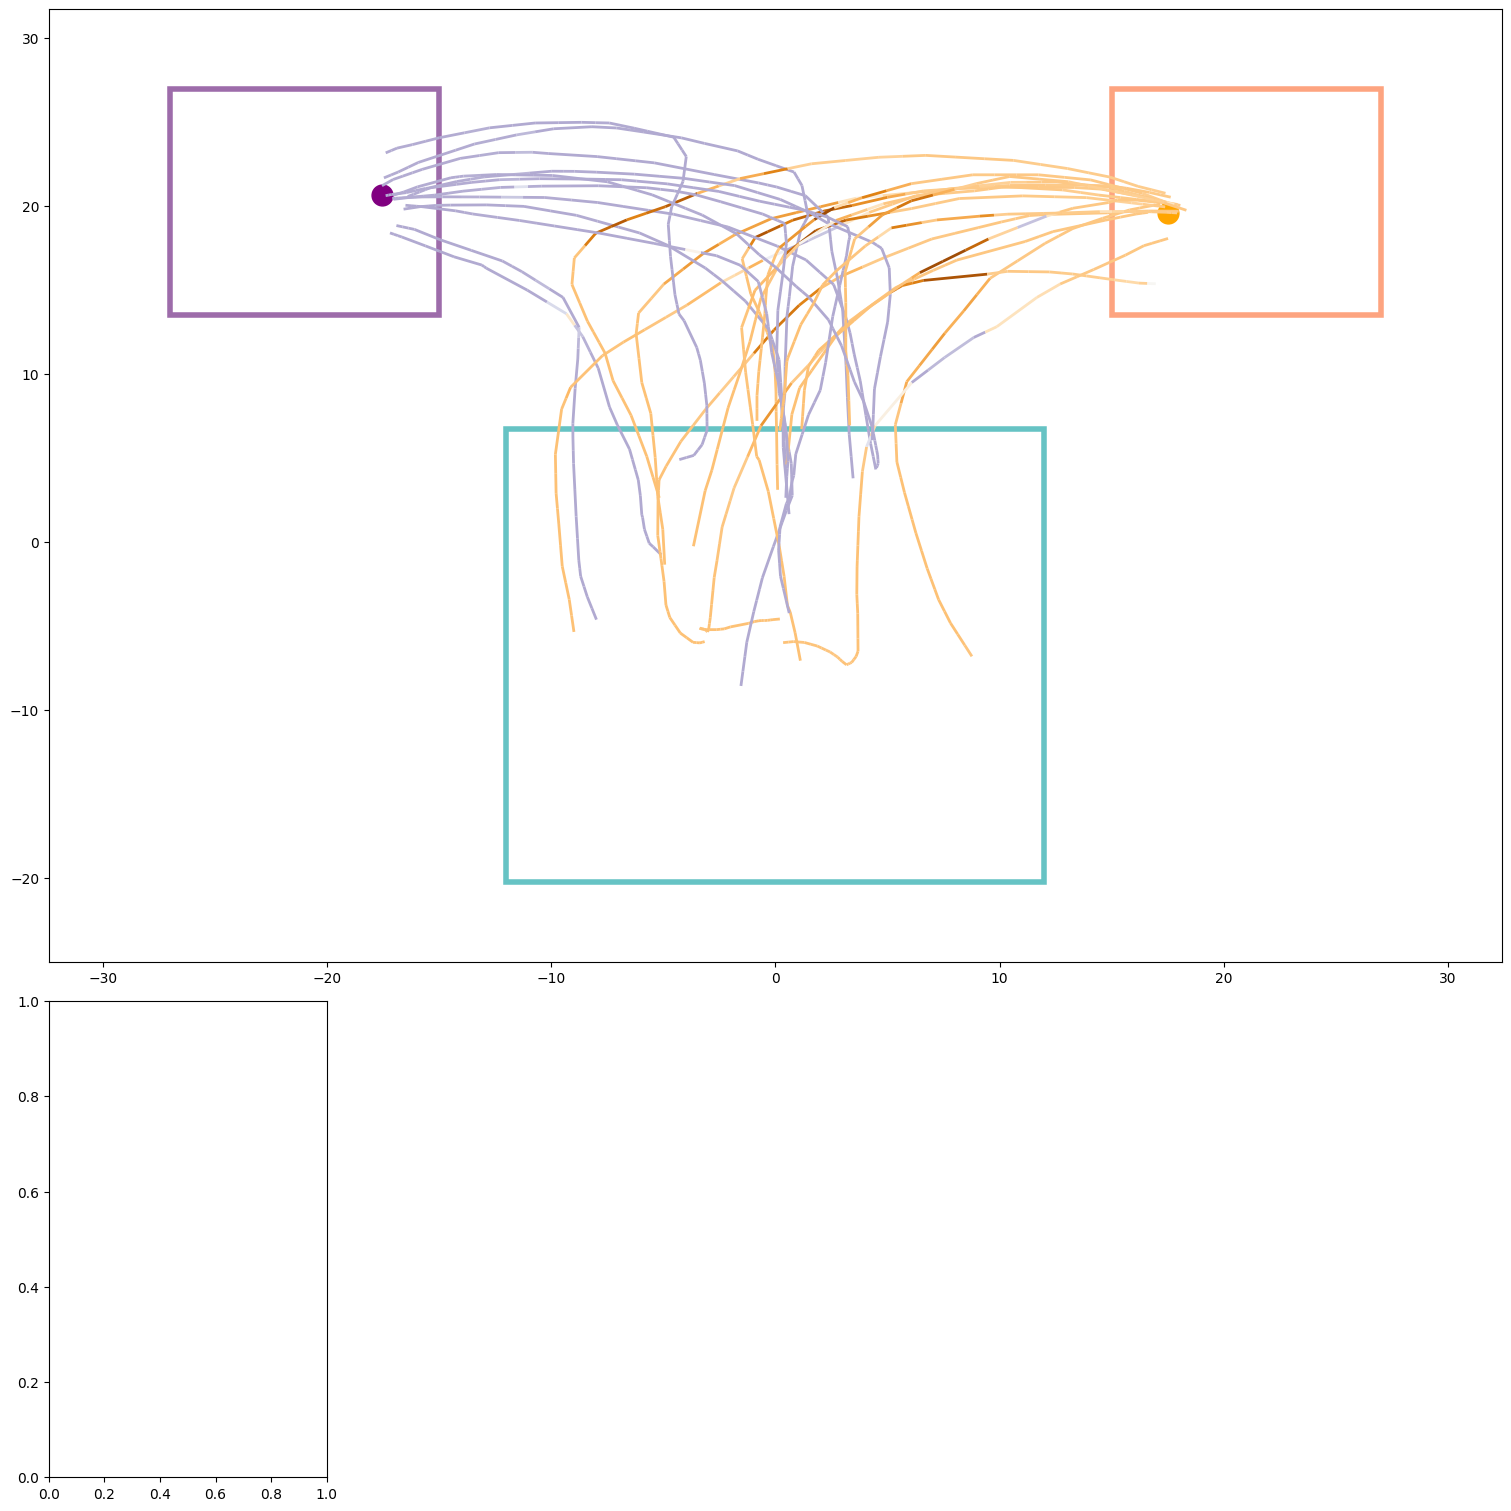

In [38]:
fig = plt.figure(figsize = (15,15), constrained_layout=True)
gs = plt.GridSpec(3, 5, figure=fig)
ax = fig.add_subplot(gs[:2, :])

colors=["red", "blue", "green", "purple", "orange"]

#for i, thr in enumerate([0.2]):#, 0.3, 0.4, 0.5]):
#print("--> computing for treshold ", thr)
ax2 = fig.add_subplot(gs[2, i])
#decision_point = df.groupby(["session", "trial"], as_index=False).apply(lambda x: regression.find_decision_point_per_trial(x, thr), include_groups=False)
plot_decision(df, df_box, color=colors[i], ax=ax, trials=list(range(10, 40)))
#regression.pair_plot(decision_point, ax=ax2)
